In [1]:
import torch
import torchvision
import random
import pandas as pd
import numpy as np
from torch import nn
from PIL import Image
import os
from pathlib import Path
import matplotlib.pyplot as plt
import time

torch.__version__



'2.7.0.dev20250127+cu126'

In [2]:

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

device

device(type='cuda', index=0)

In [3]:
!nvidia-smi

Thu Feb 13 13:57:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.36                 Driver Version: 566.36         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   52C    P8              2W /   60W |      62MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from pathlib import Path 
import os 
TRAIN_DIR = Path("tomato/train")

TEST_DIR=Path("tomato/val")

NUM_OF_CLASSES= len(os.listdir(TRAIN_DIR))

NUM_OF_CLASSES


10

In [5]:
CLASSES=os.listdir(TRAIN_DIR)

CLASSES

['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___healthy',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']

In [6]:
def walk_through_dir(dirpath):
    for dirpath,dirnames,filenames in os.walk(dirpath):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [7]:
walk_through_dir(TRAIN_DIR)

There are 10 directories and 0 images in 'tomato\train'.
There are 0 directories and 1000 images in 'tomato\train\Tomato___Bacterial_spot'.
There are 0 directories and 1000 images in 'tomato\train\Tomato___Early_blight'.
There are 0 directories and 1000 images in 'tomato\train\Tomato___healthy'.
There are 0 directories and 1000 images in 'tomato\train\Tomato___Late_blight'.
There are 0 directories and 1000 images in 'tomato\train\Tomato___Leaf_Mold'.
There are 0 directories and 1000 images in 'tomato\train\Tomato___Septoria_leaf_spot'.
There are 0 directories and 1000 images in 'tomato\train\Tomato___Spider_mites Two-spotted_spider_mite'.
There are 0 directories and 1000 images in 'tomato\train\Tomato___Target_Spot'.
There are 0 directories and 1000 images in 'tomato\train\Tomato___Tomato_mosaic_virus'.
There are 0 directories and 1000 images in 'tomato\train\Tomato___Tomato_Yellow_Leaf_Curl_Virus'.


In [8]:
def plot_train_images(base_path):
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 10))
    
    axes = axes.flatten()
    
    for i, category in enumerate(CLASSES):
        category_path = os.path.join(base_path, category)
        
        image_files = [f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if image_files:
            image_path = os.path.join(category_path, image_files[random.randrange(len(image_files))])
    
            image = Image.open(image_path)
            
            axes[i].imshow(image)
            axes[i].set_title(category)
            axes[i].axis("off")
    
    plt.tight_layout()
    axes[10].set_axis_off()
    axes[11].set_axis_off()
    plt.show()

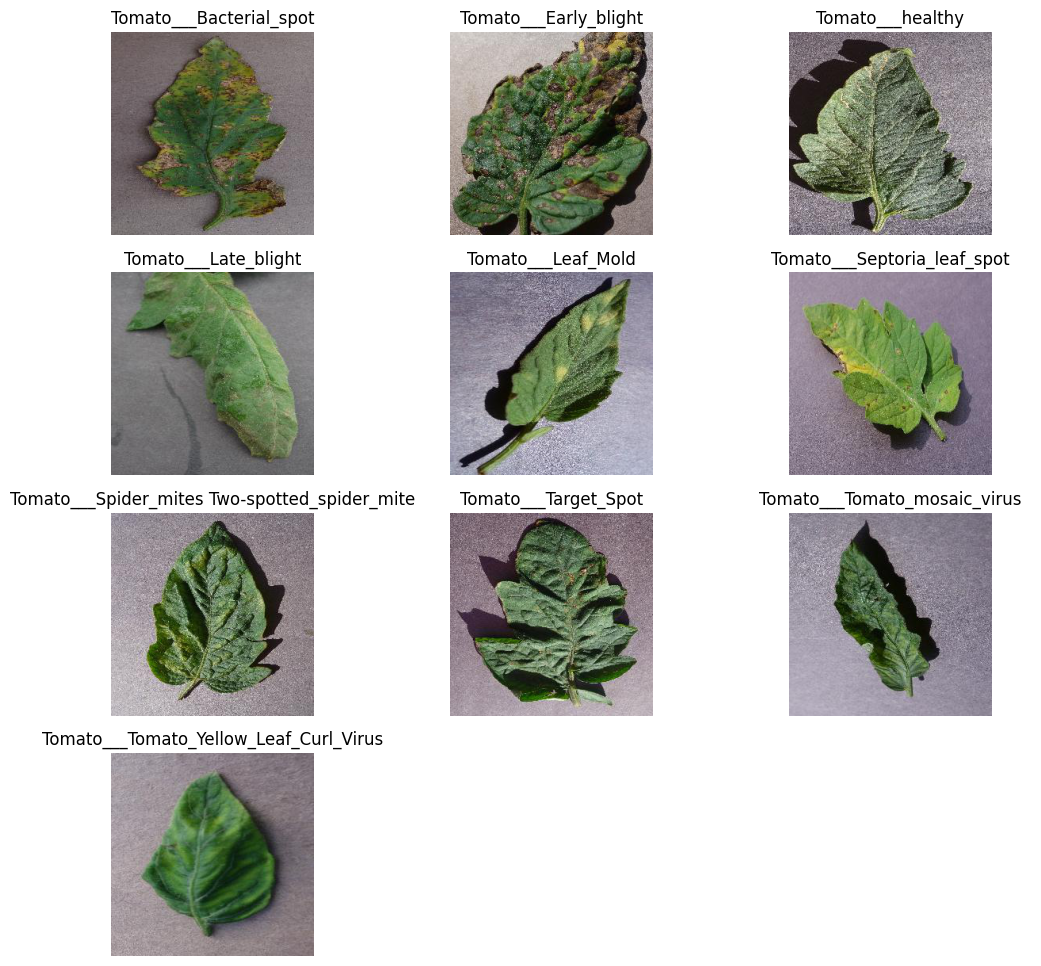

In [9]:

base_path = TRAIN_DIR 
plot_train_images(base_path)

In [10]:
from torchvision import datasets,transforms
from torch.utils.data import DataLoader

In [11]:
category_paths=[]
for i, category in enumerate(CLASSES):
        category_paths.append(os.path.join(TRAIN_DIR, category))

In [12]:
import os

def get_all_images(directories):
    
    image_list = []
    
    for directory in directories:
        if not os.path.exists(directory):
            print(f"Warning: Directory {directory} does not exist.")
            continue

        # Get all image files (filtering common image extensions)
        files = [f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        image_list.extend([Path(os.path.join(directory, f)) for f in files])
    
    return image_list

In [13]:
image_files = get_all_images(category_paths)

# Print the collected image paths
print(len(image_files))

10000


In [17]:
def plot_transformed_images(image_paths, transform, n=3):
    
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f) 
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib 
            
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0) 
            ax[1].imshow(transformed_image) 
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)


In [15]:
from torchvision import transforms

# Create simple transform
simple_transform = transforms.Compose([ 
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

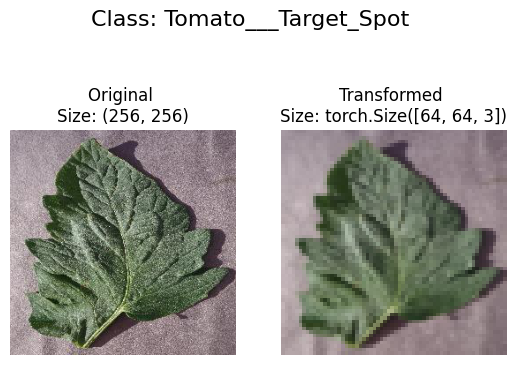

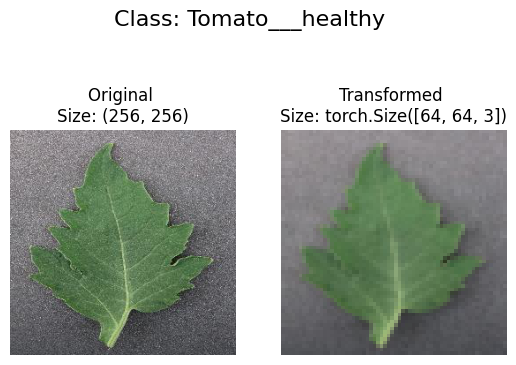

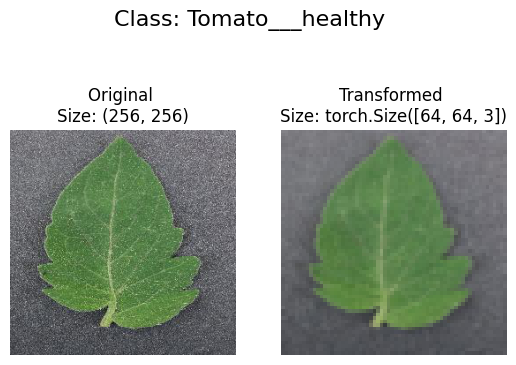

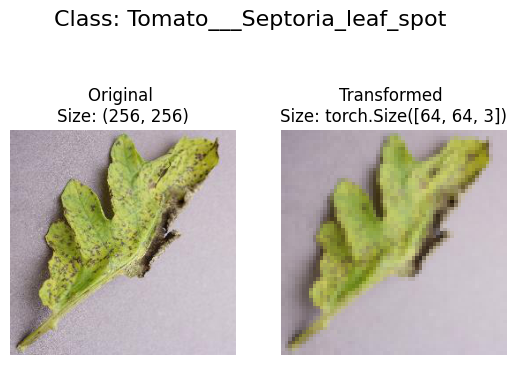

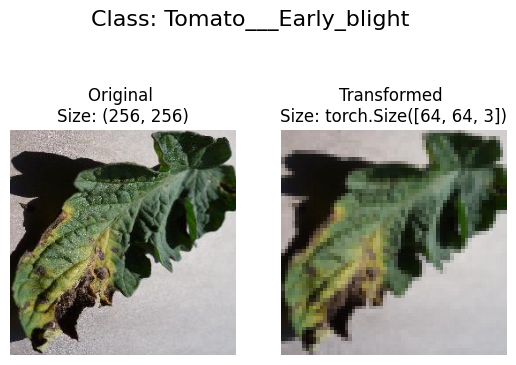

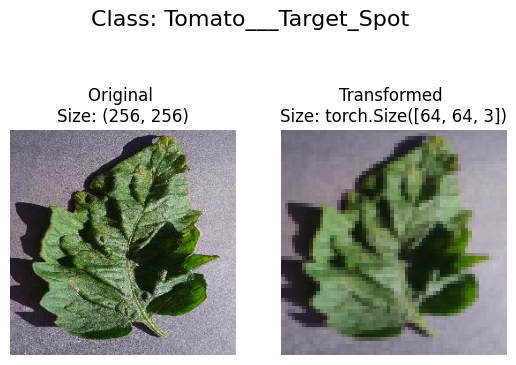

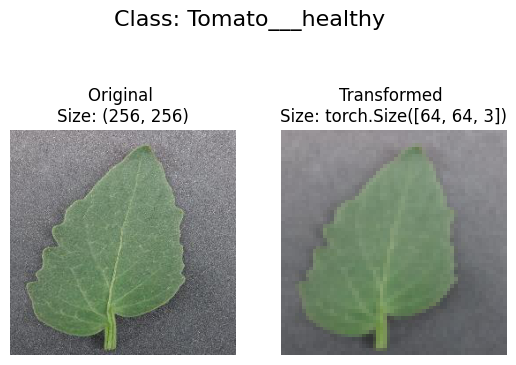

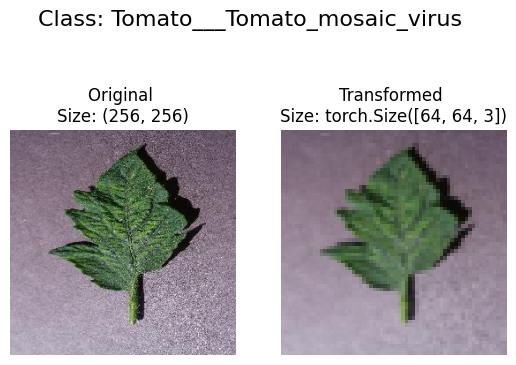

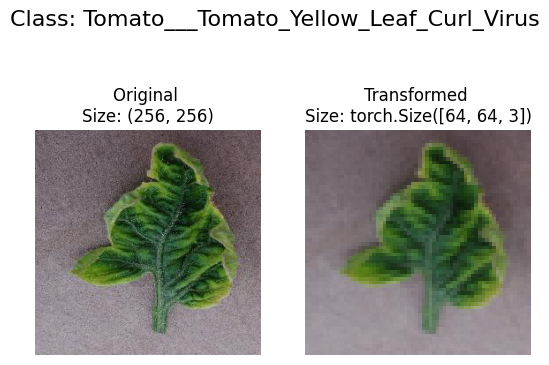

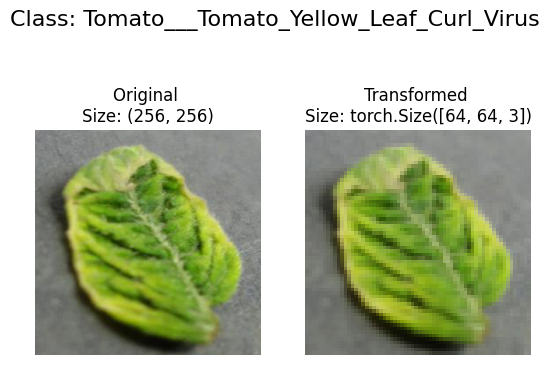

In [18]:
plot_transformed_images(image_files, 
                        transform=simple_transform, 
                        n=10)

In [19]:
os.cpu_count()

12

Creating DataLoader's with batch size 32 and 8 workers.


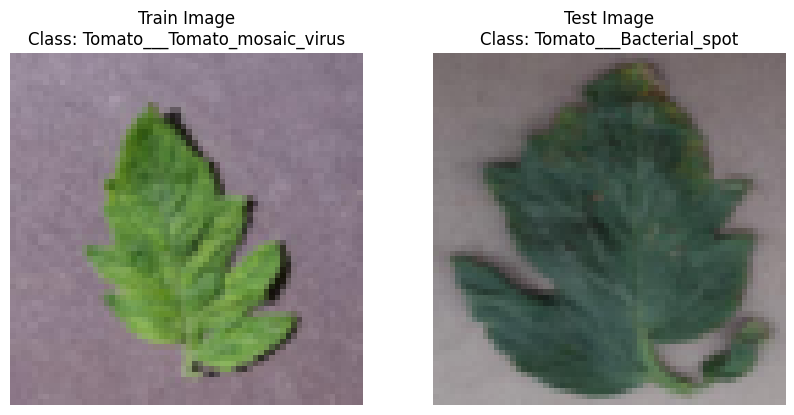

In [20]:
# 1. Load and transform data

train_data = datasets.ImageFolder(root=TRAIN_DIR, transform=simple_transform)
test_data = datasets.ImageFolder(root=TEST_DIR, transform=simple_transform)

# Setup batch size and number of workers 
BATCH_SIZE = 32
NUM_WORKERS = 8
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

# Create DataLoader's
train_dataloader = DataLoader(train_data, 
                                     batch_size=BATCH_SIZE, 
                                     shuffle=True, 
                                     num_workers=NUM_WORKERS,pin_memory=True)

test_dataloader = DataLoader(test_data, 
                                    batch_size=BATCH_SIZE, 
                                    shuffle=False, 
                                    num_workers=NUM_WORKERS,pin_memory=True)

# Get the first batch from each dataloader
train_features, train_labels = next(iter(train_dataloader))
test_features, test_labels = next(iter(test_dataloader))

# Plot the first image from each dataloader
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Train image
axes[0].imshow(train_features[0].permute(1, 2, 0))
axes[0].set_title(f"Train Image\nClass: {CLASSES[train_labels[0]]}")
axes[0].axis("off")

# Test image
axes[1].imshow(test_features[0].permute(1, 2, 0))
axes[1].set_title(f"Test Image\nClass: {CLASSES[test_labels[0]]}")
axes[1].axis("off")

plt.show()



In [22]:
test_features[0].shape

torch.Size([3, 64, 64])

In [ ]:
class TinyVGG(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, 
                      stride=1, # 
                      padding=1), 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) 
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=2560,
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # <- leverage the benefits of operator fusion

In [ ]:
len(train_data.classes)

10

In [ ]:
torch.manual_seed(42)
model = TinyVGG(input_shape=3, 
                  hidden_units=10, 
                  output_shape=len(train_data.classes))
model

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=10, bias=True)
  )
)

In [ ]:
import torchinfo
from torchinfo import summary

summary(model, input_size=[1,3, 64, 64]) 

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 10]                   --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

In [ ]:
next(model.parameters()).device

device(type='cuda', index=0)

In [ ]:
def train_step(model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer):
    
    # Put model in train mode
    model.train()
    
    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0
    
    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() 

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch 
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [ ]:
def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval() 
    
    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0
    
    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)
    
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            
    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [ ]:
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    
    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
    
    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)
        
        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [ ]:
import torch
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.device_count())  # Should be > 0
print(torch.cuda.get_device_name(0))  # Should print your GPU name
print(torch.backends.cudnn.enabled)  # Should return True


True
1
NVIDIA GeForce GTX 1650
True


In [ ]:
# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 10

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB) 
                  hidden_units=10, 
                  output_shape=len(train_data.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)


In [ ]:

print(model.parameters().__next__().device)  # Should print "cuda:0"


cuda:0


In [ ]:
# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_0 
model_0_results = train(model=model_0, 
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

 10%|█         | 1/10 [01:08<10:16, 68.53s/it]

Epoch: 1 | train_loss: 1.6415 | train_acc: 0.4178 | test_loss: 1.2195 | test_acc: 0.5977


 20%|██        | 2/10 [02:13<08:50, 66.33s/it]

Epoch: 2 | train_loss: 0.9363 | train_acc: 0.6849 | test_loss: 0.9584 | test_acc: 0.6787


 30%|███       | 3/10 [03:16<07:34, 64.93s/it]

...

Epoch: 8 | train_loss: 0.4213 | train_acc: 0.8556 | test_loss: 0.7267 | test_acc: 0.7666


 90%|█████████ | 9/10 [09:32<01:02, 62.74s/it]

Epoch: 9 | train_loss: 0.4051 | train_acc: 0.8618 | test_loss: 0.5725 | test_acc: 0.8242


100%|██████████| 10/10 [10:36<00:00, 63.67s/it]

Epoch: 10 | train_loss: 0.3673 | train_acc: 0.8765 | test_loss: 0.5724 | test_acc: 0.8174
Total training time: 636.740 seconds


In [ ]:
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    
    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot 
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

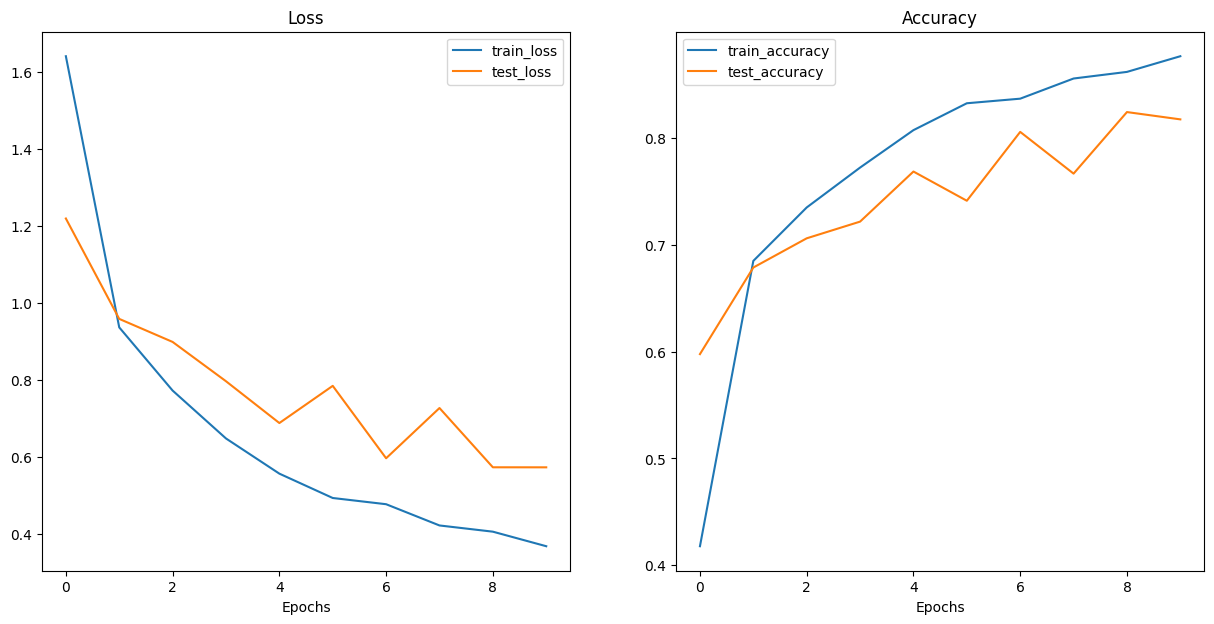

In [ ]:
plot_loss_curves(model_0_results)

In [ ]:
def infer_result(model,dataloader,index):
    img_batch, label_batch = next(iter(dataloader))

    # 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
    img_single, label_single = img_batch[index].unsqueeze(dim=0), label_batch[index]


    # 3. Perform a forward pass on a single image
    model.to(device)
    model.eval()
    with torch.inference_mode():
        pred = model(img_single.to(device))
        
    # 4. Print out what's happening and convert model logits -> pred probs -> pred label
    print(f"Output logits:\n{pred}\n")
    print(f"Output prediction label :  \n {torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
    print(f"Actual Class Label : \n {label_single}\n")


In [ ]:
infer_result(model_0,train_dataloader,0)

Output logits:
tensor([[ -3.5354,  -5.3274,  -4.9751,  -2.8856,  -7.2646,  -6.6038,  -6.3038,
           4.4868, -13.5762, -16.7294]], device='cuda:0')

Output prediction label :  
 tensor([7], device='cuda:0')

Actual Class Label : 
 7



In [ ]:
from pathlib import Path
import os
MODEL_PATH=Path("./")
MODEL_NAME="CNN.pth"

MODEL_DIR=os.path.join(MODEL_PATH,MODEL_NAME)

torch.save(obj=model_0.state_dict(),f=MODEL_DIR)

In [ ]:

model_test = TinyVGG(input_shape=3, 
                  hidden_units=10, 
                  output_shape=len(train_data.classes))

model_test.load_state_dict(torch.load(f=MODEL_DIR,weights_only=True))

for param in model.parameters():
    print(type(param), param.size())

<class 'torch.nn.parameter.Parameter'> torch.Size([10, 3, 3, 3])
<class 'torch.nn.parameter.Parameter'> torch.Size([10])
<class 'torch.nn.parameter.Parameter'> torch.Size([10, 10, 3, 3])
<class 'torch.nn.parameter.Parameter'> torch.Size([10])
<class 'torch.nn.parameter.Parameter'> torch.Size([10, 10, 3, 3])
<class 'torch.nn.parameter.Parameter'> torch.Size([10])
<class 'torch.nn.parameter.Parameter'> torch.Size([10, 10, 3, 3])
<class 'torch.nn.parameter.Parameter'> torch.Size([10])
<class 'torch.nn.parameter.Parameter'> torch.Size([10, 2560])
<class 'torch.nn.parameter.Parameter'> torch.Size([10])


In [ ]:
img_batch, label_batch = next(iter(test_dataloader))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]

dummy_input = img_single.to(device)

MODEL_PATH=Path("./")
MODEL_NAME="CNN.onnx"

MODEL_DIR=os.path.join(MODEL_PATH,MODEL_NAME)


In [ ]:
dummy_input.device

device(type='cuda', index=0)

In [ ]:
import onnx


In [ ]:

torch.onnx.export(
    model_0, 
    dummy_input, 
    MODEL_DIR,
    input_names=["input"],  
    output_names=["output"],  
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}}  
)

In [ ]:
onnx_model = onnx.load(MODEL_DIR)  # Load the ONNX model
onnx.checker.check_model(onnx_model)  # Validate the model
print("ONNX model is valid!")

ONNX model is valid!


In [ ]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession(MODEL_DIR)

# Prepare input data
input_data = img_single.numpy()

# Run inference
output = session.run(None, {"input": input_data})
print("ONNX Model Output:", output)

ONNX Model Output: [array([[  3.3246636,  -4.032516 ,  -3.4142754,  -4.3260365,  -5.6935396,
         -6.813357 ,  -2.2651184,  -3.2180684, -20.84772  ,  -6.305093 ]],
      dtype=float32)]


In [ ]:
def softmax(x):
    exp_x = np.exp(x - np.max(x))  # Subtract max for numerical stability
    return exp_x / np.sum(exp_x)

In [ ]:
probabilities = softmax(np.array(output))
predicted_class = np.argmax(probabilities)

print("Softmax Probabilities:", probabilities)
print("Predicted Class Index:", predicted_class)

Softmax Probabilities: [[[9.92358387e-01 6.33120013e-04 1.17485540e-03 4.72075801e-04
   1.20257566e-04 3.92448055e-05 3.70729528e-03 1.42953906e-03
   3.15308959e-11 6.52406452e-05]]]
Predicted Class Index: 0


In [ ]:
import onnx_graphsurgeon as gs

model = onnx.load("CNN.onnx")

# 2. Import the model into a GraphSurgeon graph
graph = gs.import_onnx(model)

# (Optional) Inspect nodes and tensors:
print("Nodes in the graph:")
for node in graph.nodes:
    print(f" - {node.name}: {node.op}")

Nodes in the graph:
 - /conv_block_1/conv_block_1.0/Conv: Conv
 - /conv_block_1/conv_block_1.1/Relu: Relu
 - /conv_block_1/conv_block_1.2/Conv: Conv
 - /conv_block_1/conv_block_1.3/Relu: Relu
 - /conv_block_1/conv_block_1.4/MaxPool: MaxPool
 - /conv_block_2/conv_block_2.0/Conv: Conv
 - /conv_block_2/conv_block_2.1/Relu: Relu
 - /conv_block_2/conv_block_2.2/Conv: Conv
 - /conv_block_2/conv_block_2.3/Relu: Relu
 - /conv_block_2/conv_block_2.4/MaxPool: MaxPool
 - /classifier/classifier.0/Flatten: Flatten
 - /classifier/classifier.1/Gemm: Gemm


In [ ]:
graph.nodes

[/conv_block_1/conv_block_1.0/Conv (Conv)
 	Inputs: [
 		Variable (input): (shape=['batch_size', 3, 64, 64], dtype=float32)
 		Constant (conv_block_1.0.weight): (shape=[10, 3, 3, 3], dtype=float32)
 		Constant (conv_block_1.0.bias): (shape=[10], dtype=float32)
 	]
 	Outputs: [
 		Variable (/conv_block_1/conv_block_1.0/Conv_output_0): (shape=None, dtype=None)
 	]
 Attributes: OrderedDict({'dilations': [1, 1], 'group': 1, 'kernel_shape': [3, 3], 'pads': [1, 1, 1, 1], 'strides': [1, 1]}),
 /conv_block_1/conv_block_1.1/Relu (Relu)
 	Inputs: [
 		Variable (/conv_block_1/conv_block_1.0/Conv_output_0): (shape=None, dtype=None)
 	]
 	Outputs: [
 		Variable (/conv_block_1/conv_block_1.1/Relu_output_0): (shape=None, dtype=None)
 	],
 /conv_block_1/conv_block_1.2/Conv (Conv)
 	Inputs: [
 		Variable (/conv_block_1/conv_block_1.1/Relu_output_0): (shape=None, dtype=None)
 		Constant (conv_block_1.2.weight): (shape=[10, 10, 3, 3], dtype=float32)
 		Constant (conv_block_1.2.bias): (shape=[10], dtype=f